In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from anonymeter.evaluators import SinglingOutEvaluator
from anonymeter.evaluators import LinkabilityEvaluator
from anonymeter.evaluators import InferenceEvaluator 
import sys
parent_dir = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline"
sys.path.append(parent_dir)
from SynOmics.processing.postprocessing import post_masking

import logging
seed = 42
logging.basicConfig(filename=f"anonymeter_linkability_{seed}.log", level=logging.DEBUG)

ori = pd.read_csv("../Data/original_data.csv", index_col = 0)
masked_ori = post_masking(ori)
masked_ori.columns = [col.replace('.', '_') for col in masked_ori.columns]

In [21]:
syn_datas = ["original_data",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
# tools = ["AvatarsK5", "AvatarsK10", "CTGAN","GaussianCopula", "TVAE","Synthpop"]
synthetic_dict = {}
for syn_data in syn_datas:
    syn_df = pd.read_csv(f"../Data/{syn_data}.csv", index_col = 0)
    masked_syn_df = post_masking(syn_df)
    masked_syn_df.columns = [col.replace('.', '_') for col in masked_syn_df.columns]
    synthetic_dict[syn_data] = masked_syn_df

In [23]:
import random
import pickle
from SynOmics.utils.monitoring import monitor_resources

cols = ori.columns.tolist()
@monitor_resources
def linkability_genes_clinical(ori, syns, n_neighbors):
    results_dict = {}
    for syn, syn_df in syns.items():
        print(f"----{syn}----")
        random.seed(42)
        cols = ori.columns.tolist()
        genes_cols = ori.columns.tolist()[47:]
        clinical_cols = ori.columns.tolist()[:47]  
        risks = []
        proportions = [0.1,0.25,0.50, 0.75,1]
        for p in proportions:
            n = int(len(genes_cols) * p)
            
            sampled_genes_cols = random.sample(genes_cols, n)
            print(f"Sample {len(sampled_genes_cols)} cols among {len(genes_cols)}")
            aux_cols = [clinical_cols, sampled_genes_cols]
            evaluator = LinkabilityEvaluator(ori=ori, 
                                             syn=syn_df, 
                                             n_attacks=ori.shape[0],
                                             aux_cols=aux_cols,
                                             n_neighbors=n_neighbors)
            evaluator.evaluate(n_jobs=-2)  # n_jobs follow joblib convention. -1 = all cores, -2 = all execept one
            evaluator.risk()
            print(f"{p}", evaluator.risk(n_neighbors=n_neighbors))
            risks.append(evaluator.risk(n_neighbors=n_neighbors).value)
        results_dict[syn] = risks
    return results_dict
linkability_res_genes_to_clinical = linkability_genes_clinical(masked_ori, synthetic_dict, n_neighbors = 1)

# Define the filename
linkability_results = f"LinkabilityResults_{seed}.pkl"

# --- Saving the dictionary (using 'wb' for 'write binary') ---
try:
    with open(linkability_results, 'wb') as file:
        pickle.dump(linkability_res_genes_to_clinical, file)
    print(f"Dictionary successfully saved to **{linkability_results}**.")
except Exception as e:
    print(f"An error occurred while saving: {e}")

--- System & Process Info ---
Current Date and Time (UTC): 2025-12-01 16:25:22
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 48
Logical Processors: 48
Process RAM before execution: 826.92 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---
----original_data----
Sample 1876 cols among 18760
0.1 PrivacyRisk(value=0.9846146510262609, ci=(0.9692293020525218, 1.0))
Sample 4690 cols among 18760
0.25 PrivacyRisk(value=0.9846146510262609, ci=(0.9692293020525218, 1.0))
Sample 9380 cols among 18760
0.5 PrivacyRisk(value=0.9846146510262609, ci=(0.9692293020525218, 1.0))
Sample 14070 cols among 18760
0.75 PrivacyRisk(value=0.9846146510262609, ci=(0.9692293020525218, 1.0))
Sample 18760 cols among 18760
1 PrivacyRisk(value=0.9846146510262609, ci=(0.9692293020525218, 1.0))
----avatarsk10_42----
Sample 1876 cols among 18760
0.1 Privacy

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.015385348973739133, baseline = 0.023395508494834353. Analysis results cannot be trusted.
  self._sanity_check()


0.1 PrivacyRisk(value=0.015385348973739133, ci=(0.0, 0.03077069794747827))
Sample 4690 cols among 18760


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.015385348973739133, baseline = 0.023395508494834353. Analysis results cannot be trusted.
  self._sanity_check()


0.25 PrivacyRisk(value=0.015385348973739133, ci=(0.0, 0.03077069794747827))
Sample 9380 cols among 18760


...

0.1 PrivacyRisk(value=0.023395508494834353, ci=(0.0014603733854198324, 0.04533064360424888))
Sample 4690 cols among 18760
0.25 PrivacyRisk(value=0.023395508494834353, ci=(0.0014603733854198324, 0.04533064360424888))
Sample 9380 cols among 18760
0.5 PrivacyRisk(value=0.023395508494834353, ci=(0.0014603733854198324, 0.04533064360424888))
Sample 14070 cols among 18760


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.023395508494834353, baseline = 0.031405668015929575. Analysis results cannot be trusted.
  self._sanity_check()


0.75 PrivacyRisk(value=0.023395508494834353, ci=(0.0014603733854198324, 0.04533064360424888))
Sample 18760 cols among 18760


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.023395508494834353, baseline = 0.023395508494834353. Analysis results cannot be trusted.
  self._sanity_check()


1 PrivacyRisk(value=0.023395508494834353, ci=(0.0014603733854198324, 0.04533064360424888))
----tvae_42----
Sample 1876 cols among 18760
0.1 PrivacyRisk(value=0.05543614657921524, ci=(0.017777486075125137, 0.09309480708330534))
Sample 4690 cols among 18760
0.25 PrivacyRisk(value=0.03941582753702479, ci=(0.008467314305269855, 0.07036434076877973))
Sample 9380 cols among 18760
0.5 PrivacyRisk(value=0.05543614657921524, ci=(0.017777486075125137, 0.09309480708330534))
Sample 14070 cols among 18760
0.75 PrivacyRisk(value=0.05543614657921524, ci=(0.017777486075125137, 0.09309480708330534))
Sample 18760 cols among 18760
1 PrivacyRisk(value=0.05543614657921524, ci=(0.017777486075125137, 0.09309480708330534))

--- Resource Usage Summary ---
Execution time: 129.026803 seconds
Process RAM after execution: 866.54 MB
Process RAM used by function: 39.62 MB
Average per-core CPU during execution: [100.0, 24.6, 100.0, 12.3, 100.0, 11.1, 100.0, 26.6, 100.0, 30.2, 100.0, 6.2, 100.0, 10.4, 100.0, 8.7, 0.3,

/tmp/ipykernel_2865504/2871353889.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(means.index, rotation=45, ha='right')


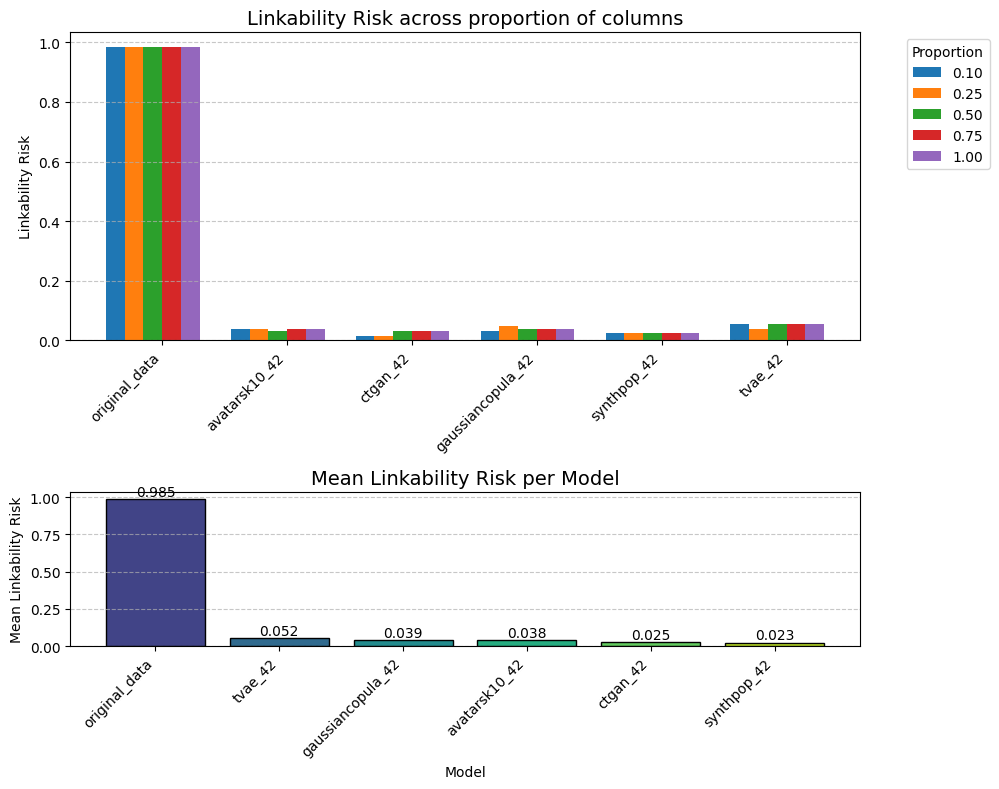

In [24]:
# --- Your data ---
results = linkability_res_genes_to_clinical
proportions = [0.1, 0.25, 0.5, 0.75, 1.0]
df = pd.DataFrame(results, index=proportions)

# Compute mean per model for lower plot
means = df.mean().sort_values(ascending=False)

# --- Create subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1])
plt.subplots_adjust(hspace=0.4)

x = np.arange(len(df.columns))  # models on x-axis
width = 0.15                    # width of each bar
# colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(proportions)))

for i, p in enumerate(proportions):
    axes[0].bar(x + i*width - (width*len(proportions)/2), df.loc[p], width,
                label=f"{p:.2f}")

axes[0].set_title("Linkability Risk across proportion of columns", fontsize=14)
axes[0].set_ylabel("Linkability Risk")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df.columns, rotation=45, ha='right')
axes[0].legend(title="Proportion", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 🎯 2️⃣ Lower plot — mean performance
colors_mean = plt.cm.viridis(np.linspace(0.2, 0.9, len(means)))
bars = axes[1].bar(means.index, means.values, color=colors_mean, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.001,
                 f"{height:.3f}", ha='center', va='bottom', fontsize=10)

axes[1].set_title("Mean Linkability Risk per Model", fontsize=14)
axes[1].set_ylabel("Mean Linkability Risk")
axes[1].set_xlabel("Model")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_xticklabels(means.index, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f"Linkability_{seed}.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:

LinkabilityResults_df = pd.DataFrame(linkability_res_genes_to_clinical)
LinkabilityResults_df["Case"] = proportions
LinkabilityResults_df.to_csv(f"LinkabilityResults_{seed}.csv", index = False)